# Customer Analytics EDA

**Banking Analytics Intelligence Platform** — Tanzania Banking Portfolio

This notebook analyzes customer demographics, regional distribution, account value, and rule-based segmentation to support retail banking strategy decisions.


In [1]:
# Reusable analysis utilities and configuration
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'customer_analysis'
CHART_DIR = REPORT_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PREMIUM_BALANCE_THRESHOLD = 5_000_000
LOW_VALUE_BALANCE_THRESHOLD = 500_000
HIGH_ACTIVITY_ACCOUNT_THRESHOLD = 3


def load_customer_datasets(processed_dir: Path = PROCESSED_DIR):
    """Load cleaned customer and account datasets for analytics."""
    customers = pd.read_csv(processed_dir / 'customers_clean.csv', parse_dates=['date_of_birth', 'customer_since'])
    accounts = pd.read_csv(processed_dir / 'accounts_clean.csv', parse_dates=['opening_date'])
    return customers, accounts


def summarize_dataset(df: pd.DataFrame, name: str) -> None:
    """Display structural overview for a banking dataset."""
    print(f'\n=== {name} ===')
    display(df.head())
    print(f'Shape: {df.shape}')
    print('Columns:', list(df.columns))
    print('\nData types:')
    print(df.dtypes)


def build_kpi_summary(customers: pd.DataFrame, accounts: pd.DataFrame) -> pd.DataFrame:
    """Compute executive KPIs for customer portfolio reporting."""
    premium_count = (customers['customer_type'] == 'Premium').sum()
    kpis = {
        'Metric': [
            'Total Customers',
            'Total Accounts',
            'Average Customer Age',
            'Premium Customers',
            'Standard Customers',
            'Basic Customers',
            'Male Customers',
            'Female Customers',
        ],
        'Value': [
            f"{len(customers):,}",
            f"{len(accounts):,}",
            f"{customers['age'].mean():.1f} years",
            f"{premium_count:,}",
            f"{(customers['customer_type'] == 'Standard').sum():,}",
            f"{(customers['customer_type'] == 'Basic').sum():,}",
            f"{(customers['gender'] == 'Male').sum():,}",
            f"{(customers['gender'] == 'Female').sum():,}",
        ],
    }
    return pd.DataFrame(kpis)


def age_group_summary(customers: pd.DataFrame) -> pd.DataFrame:
    """Summarize customer distribution across age bands."""
    order = ['18-30', '31-45', '46-60', '60+']
    summary = (
        customers['customer_age_group']
        .value_counts()
        .reindex(order)
        .rename_axis('Age Group')
        .reset_index(name='Customers')
    )
    summary['Percentage'] = (summary['Customers'] / summary['Customers'].sum() * 100).round(1).astype(str) + '%'
    return summary


def region_summary(customers: pd.DataFrame) -> pd.DataFrame:
    """Summarize customer concentration by Tanzania region."""
    summary = (
        customers.groupby('region', as_index=False)
        .size()
        .rename(columns={'size': 'customer_count'})
        .sort_values('customer_count', ascending=False)
    )
    summary['percentage'] = (summary['customer_count'] / summary['customer_count'].sum() * 100).round(2)
    return summary


def customer_account_profile(customers: pd.DataFrame, accounts: pd.DataFrame) -> pd.DataFrame:
    """Aggregate account balances and counts at customer level."""
    account_metrics = (
        accounts.groupby('customer_id', as_index=False)
        .agg(total_balance=('balance', 'sum'), account_count=('account_id', 'count'))
    )
    return customers.merge(account_metrics, on='customer_id', how='left').fillna({'total_balance': 0, 'account_count': 0})


def assign_customer_segment(row: pd.Series) -> str:
    """Apply rule-based banking segmentation without machine learning."""
    if row['total_balance'] > PREMIUM_BALANCE_THRESHOLD:
        return 'Premium'
    if row['account_count'] >= HIGH_ACTIVITY_ACCOUNT_THRESHOLD:
        return 'High Activity'
    if row['total_balance'] < LOW_VALUE_BALANCE_THRESHOLD:
        return 'Low Value'
    return 'Standard'


def save_figure(fig, filename: str) -> Path:
    """Persist a chart for management reporting packs."""
    output_path = CHART_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_path


## Section 1: Import Libraries and Load Data

Load cleaned customer and account datasets from the processed data layer.

In [2]:
customers, accounts = load_customer_datasets()
summarize_dataset(customers, 'Customers')
summarize_dataset(accounts, 'Accounts')



=== Customers ===


,customer_id,full_name,gender,date_of_birth,age,region,occupation,income_level,customer_since,customer_type,customer_age_group
0,CUST000001,Allison Hill,Male,1984-09-01,41,Zanzibar,Self Employed,Medium,2015-08-31,Basic,31-45
1,CUST000002,Noah Rhodes,Female,1955-10-05,70,Kilimanjaro,Self Employed,Low,2009-03-05,Basic,60+
2,CUST000003,Angie Henderson,Female,1997-11-18,28,Morogoro,Self Employed,Medium,2014-05-16,Standard,18-30
3,CUST000004,Daniel Wagner,Male,2006-12-06,19,Mbeya,Self Employed,Medium,2024-12-26,Standard,18-30
4,CUST000005,Cristian Santos,Male,1972-08-29,53,Dar es Salaam,Bank Officer,Low,2021-02-14,Basic,46-60


Shape: (100000, 11)
Columns: ['customer_id', 'full_name', 'gender', 'date_of_birth', 'age', 'region', 'occupation', 'income_level', 'customer_since', 'customer_type', 'customer_age_group']

Data types:
customer_id                      str
full_name                        str
gender                           str
date_of_birth         datetime64[us]
age                            int64
region                           str
occupation                       str
income_level                     str
customer_since        datetime64[us]
customer_type                    str
customer_age_group               str
dtype: object

=== Accounts ===


,account_id,customer_id,account_type,opening_date,balance,currency,status
0,ACC0000001,CUST008926,Fixed Deposit,2015-12-31,447114300,TZS,Active
1,ACC0000002,CUST077396,Current,2026-04-18,71319700,TZS,Active
2,ACC0000003,CUST065458,Current,2014-09-29,16575600,TZS,Active
3,ACC0000004,CUST043888,Savings,2012-03-05,30000000,TZS,Active
4,ACC0000005,CUST043302,Current,2018-03-13,80000000,TZS,Active


Shape: (150000, 7)
Columns: ['account_id', 'customer_id', 'account_type', 'opening_date', 'balance', 'currency', 'status']

Data types:
account_id                 str
customer_id                str
account_type               str
opening_date    datetime64[us]
balance                  int64
currency                   str
status                     str
dtype: object


## Section 2: Customer Overview Statistics

Executive KPIs used by bank management to monitor portfolio size and composition.

In [3]:
kpi_summary = build_kpi_summary(customers, accounts)
display(kpi_summary)

gender_distribution = customers['gender'].value_counts(normalize=True).mul(100).round(1)
customer_type_distribution = customers['customer_type'].value_counts(normalize=True).mul(100).round(1)
regional_distribution = customers['region'].value_counts(normalize=True).mul(100).round(1).head()

print('\nGender distribution (%):')
print(gender_distribution)
print('\nCustomer type distribution (%):')
print(customer_type_distribution)
print('\nTop regions (%):')
print(regional_distribution)


,Metric,Value
0,Total Customers,"100,000"
1,Total Accounts,"150,000"
2,Average Customer Age,46.1 years
3,Premium Customers,"15,001"
4,Standard Customers,"54,827"
5,Basic Customers,"30,172"
6,Male Customers,"49,911"
7,Female Customers,"50,089"



Gender distribution (%):
gender
Female    50.1
Male      49.9
Name: proportion, dtype: float64

Customer type distribution (%):
customer_type
Standard    54.8
Basic       30.2
Premium     15.0
Name: proportion, dtype: float64

Top regions (%):
region
Tabora      10.2
Tanga       10.1
Mwanza      10.1
Morogoro    10.0
Mbeya       10.0
Name: proportion, dtype: float64


## Section 3: Customer Demographic Analysis

### Age Distribution
Business question: *What age groups does the bank serve most?*


,Age Group,Customers,Percentage
0,18-30,22548,22.5%
1,31-45,26340,26.3%
2,46-60,26529,26.5%
3,60+,24583,24.6%


/tmp/ipykernel_195512/797061095.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_summary, x='Age Group', y='Customers', palette='Blues_d', ax=ax)


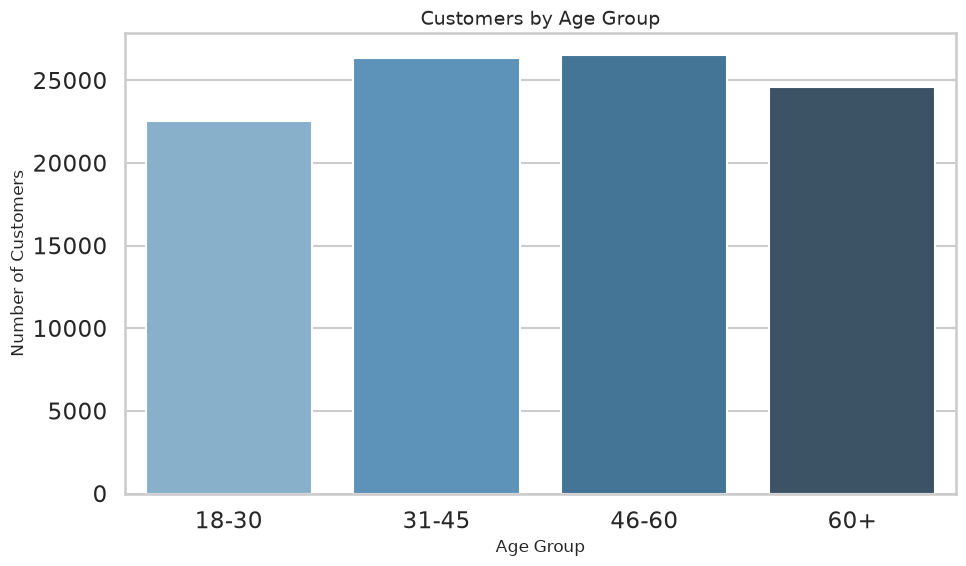

In [4]:
age_summary = age_group_summary(customers)
display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(customers['age'], bins=20, kde=True, ax=axes[0], color='#1f4e79')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Customers')

sns.boxplot(y=customers['age'], ax=axes[1], color='#2e75b6')
axes[1].set_title('Customer Age Spread')
axes[1].set_ylabel('Age (years)')
plt.tight_layout()
save_figure(fig, 'age_distribution.png')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=age_summary, x='Age Group', y='Customers', palette='Blues_d', ax=ax)
ax.set_title('Customers by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Gender Analysis

,Gender,Customers
0,Female,50089
1,Male,49911


/tmp/ipykernel_195512/2476568755.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_counts, x='Gender', y='Customers', palette='pastel', ax=axes[1])


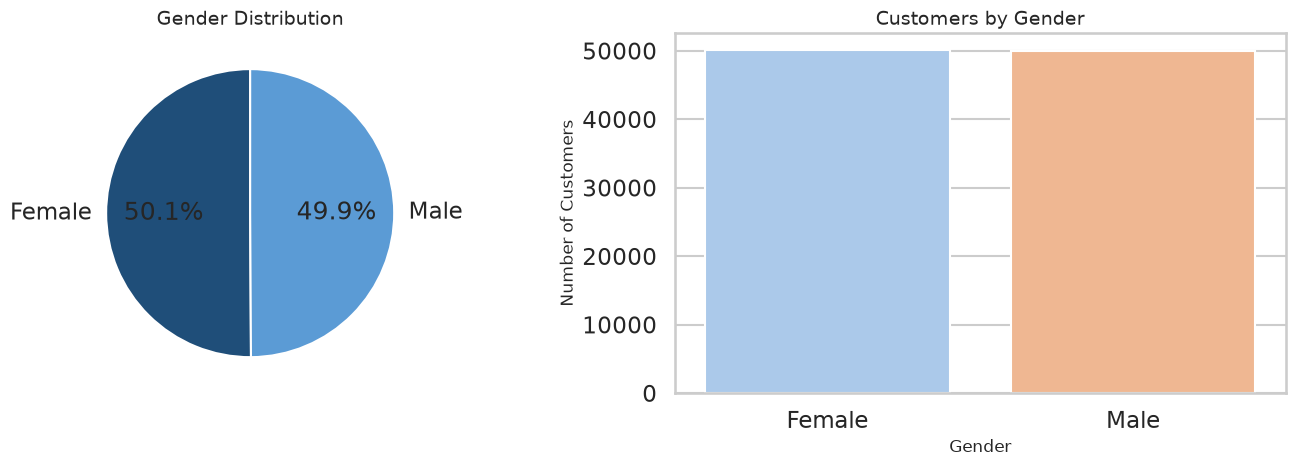

Insight: Customer base has balanced gender representation (49.9% Male, 50.1% Female).


In [5]:
gender_counts = customers['gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Customers']
display(gender_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(gender_counts['Customers'], labels=gender_counts['Gender'], autopct='%1.1f%%', startangle=90, colors=['#1f4e79', '#5b9bd5'])
axes[0].set_title('Gender Distribution')

sns.barplot(data=gender_counts, x='Gender', y='Customers', palette='pastel', ax=axes[1])
axes[1].set_title('Customers by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

male_pct = gender_counts.set_index('Gender').loc['Male', 'Customers'] / gender_counts['Customers'].sum() * 100
female_pct = 100 - male_pct
print(f'Insight: Customer base has balanced gender representation ({male_pct:.1f}% Male, {female_pct:.1f}% Female).')


### Occupation Analysis

,Occupation,Customers
0,Farmer,6809
1,Retail Worker,6784
2,Healthcare Worker,6770
3,Engineer,6750
4,Business Owner,6737
5,Nurse,6683
6,Driver,6673
7,Civil Servant,6661
8,Self Employed,6640
9,Bank Officer,6618


/tmp/ipykernel_195512/873063621.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occupation_summary, y='Occupation', x='Customers', palette='viridis', ax=ax)


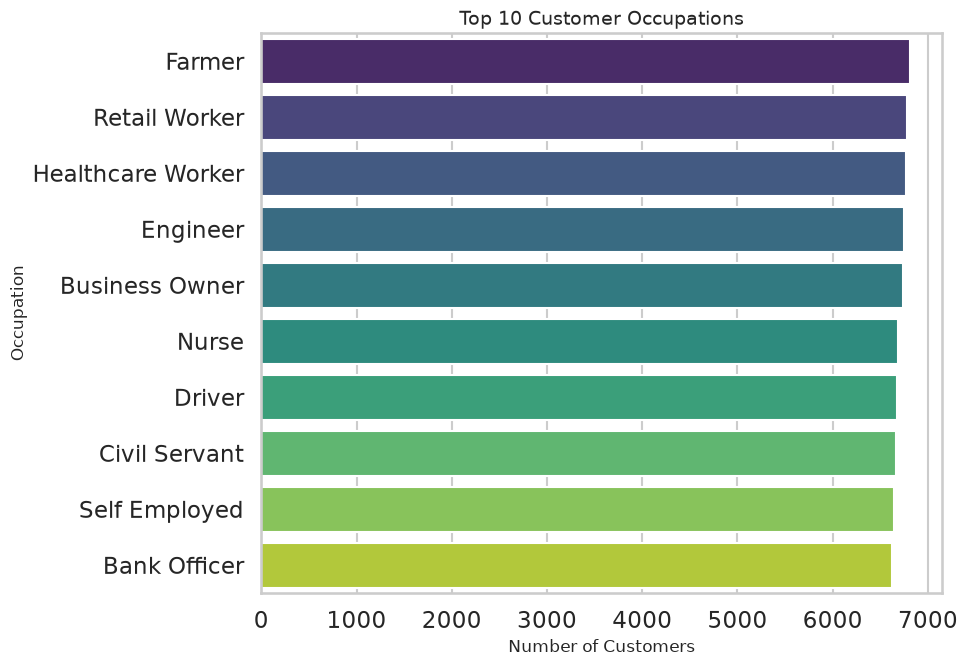

In [6]:
occupation_summary = (
    customers['occupation']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'count': 'Customers', 'occupation': 'Occupation'})
)
display(occupation_summary)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=occupation_summary, y='Occupation', x='Customers', palette='viridis', ax=ax)
ax.set_title('Top 10 Customer Occupations')
ax.set_xlabel('Number of Customers')
ax.set_ylabel('Occupation')
plt.tight_layout()
plt.show()


## Section 4: Regional Customer Analysis

Questions:
- Which regions have the highest customers?
- Which regions are underserved?


In [7]:
region_df = region_summary(customers)
display(region_df)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=region_df, x='region', y='customer_count', palette='crest', ax=ax)
ax.set_title('Customer Distribution by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_figure(fig, 'customer_by_region.png')
plt.show()

top_region = region_df.iloc[0]['region']
bottom_region = region_df.iloc[-1]['region']
print(f'Highest concentration: {top_region}')
print(f'Most underserved region: {bottom_region}')

fig_px = px.bar(region_df, x='region', y='customer_count', hover_data=['percentage'], title='Interactive Regional Customer Distribution')
fig_px.update_layout(xaxis_title='Region', yaxis_title='Number of Customers')
fig_px.show()


,region,customer_count,percentage
7,Tabora,10153,10.15
8,Tanga,10091,10.09
6,Mwanza,10069,10.07
5,Morogoro,10033,10.03
4,Mbeya,10013,10.01
9,Zanzibar,9980,9.98
2,Dodoma,9966,9.97
1,Dar es Salaam,9909,9.91
3,Kilimanjaro,9899,9.90
0,Arusha,9887,9.89


/tmp/ipykernel_195512/3522204690.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_df, x='region', y='customer_count', palette='crest', ax=ax)


Highest concentration: Tabora
Most underserved region: Arusha


## Section 5: Customer Value Analysis

Merge customer profiles with account balances to estimate customer value by segment.

,customer_type,average_balance_tzs
0,Basic,"72,534,135 TZS"
1,Premium,"72,134,952 TZS"
2,Standard,"71,352,258 TZS"


/tmp/ipykernel_195512/2788475968.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_by_type, x='customer_type', y='average_balance', palette='mako', ax=ax)


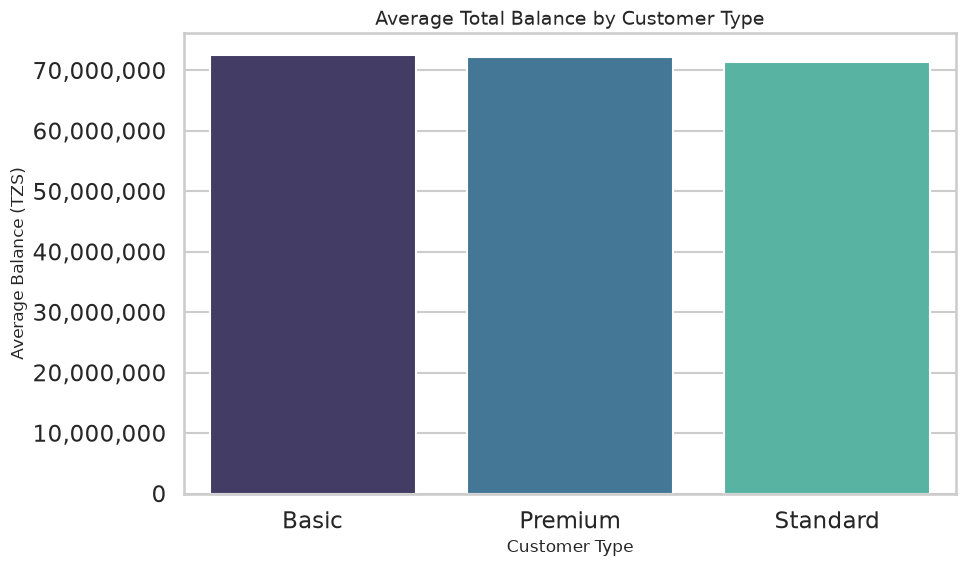

In [8]:
customer_value = customer_account_profile(customers, accounts)

value_by_type = (
    customer_value.groupby('customer_type', as_index=False)['total_balance']
    .mean()
    .rename(columns={'total_balance': 'average_balance'})
    .sort_values('average_balance', ascending=False)
)
value_by_type['average_balance_tzs'] = value_by_type['average_balance'].map(lambda x: f'{x:,.0f} TZS')
display(value_by_type[['customer_type', 'average_balance_tzs']])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=value_by_type, x='customer_type', y='average_balance', palette='mako', ax=ax)
ax.set_title('Average Total Balance by Customer Type')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Average Balance (TZS)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


## Section 6: Customer Segmentation (Rule-Based)

Simple banking segments based on balance and account activity — no machine learning.

In [9]:
segmented_customers = customer_value.copy()
segmented_customers['customer_segment'] = segmented_customers.apply(assign_customer_segment, axis=1)

segment_distribution = (
    segmented_customers['customer_segment']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'customers', 'customer_segment': 'segment'})
)
display(segmented_customers[['customer_id', 'customer_segment']].head(10))
display(segment_distribution)

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=segmented_customers, x='customer_segment', order=segment_distribution['segment'], palette='Set2', ax=ax)
ax.set_title('Rule-Based Customer Segments')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
save_figure(fig, 'customer_segments.png')
plt.show()


,customer_id,customer_segment
0,CUST000001,Premium
1,CUST000002,Premium
2,CUST000003,Premium
3,CUST000004,Low Value
4,CUST000005,Premium
5,CUST000006,Premium
6,CUST000007,Premium
7,CUST000008,Premium
8,CUST000009,Low Value
9,CUST000010,Premium


,segment,customers
0,Premium,74684
1,Low Value,23341
2,Standard,1973
3,High Activity,2


/tmp/ipykernel_195512/2152146568.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=segmented_customers, x='customer_segment', order=segment_distribution['segment'], palette='Set2', ax=ax)


## Section 7: Key Business Insights

The insights below are generated from the analysis outputs above and support retail banking strategy.


In [10]:
insights = []

premium_pct = (customers['customer_type'] == 'Premium').mean() * 100
top_age_group = age_summary.sort_values('Customers', ascending=False).iloc[0]
top_region_row = region_df.iloc[0]
bottom_region_row = region_df.iloc[-1]
avg_age = customers['age'].mean()
avg_balance_premium = value_by_type.loc[value_by_type['customer_type'] == 'Premium', 'average_balance'].iloc[0]
avg_balance_basic = value_by_type.loc[value_by_type['customer_type'] == 'Basic', 'average_balance'].iloc[0]
largest_segment = segment_distribution.iloc[0]
top_occupation = occupation_summary.iloc[0]['Occupation']
accounts_per_customer = len(accounts) / len(customers)
high_activity_pct = (segmented_customers['customer_segment'] == 'High Activity').mean() * 100
low_value_pct = (segmented_customers['customer_segment'] == 'Low Value').mean() * 100

insights.extend([
    f"1. Premium customers represent {premium_pct:.1f}% of the customer base.",
    f"2. {top_region_row['region']} has the highest customer concentration at {top_region_row['percentage']:.1f}%.",
    f"3. Customers aged {top_age_group['Age Group']} form the largest customer group ({top_age_group['Percentage']}).",
    f"4. Average customer age is {avg_age:.1f} years, indicating a mature retail banking clientele.",
    f"5. Premium customers hold an average balance of {avg_balance_premium:,.0f} TZS versus {avg_balance_basic:,.0f} TZS for Basic customers.",
    f"6. {bottom_region_row['region']} is the most underserved region with only {bottom_region_row['percentage']:.1f}% of customers.",
    f"7. The largest rule-based segment is '{largest_segment['segment']}' with {largest_segment['customers']:,} customers.",
    f"8. '{top_occupation}' is the most common occupation, suggesting targeted product bundles for this segment.",
    f"9. Customers hold an average of {accounts_per_customer:.2f} accounts, supporting cross-sell opportunities.",
    f"10. High Activity customers account for {high_activity_pct:.1f}% of the portfolio and may benefit from relationship-manager outreach.",
    f"11. Low Value customers represent {low_value_pct:.1f}% of the base and are candidates for financial literacy and savings campaigns.",
    "12. Balanced gender representation supports inclusive product design across retail banking channels.",
])

for insight in insights:
    print(insight)


1. Premium customers represent 15.0% of the customer base.
2. Tabora has the highest customer concentration at 10.2%.
3. Customers aged 46-60 form the largest customer group (26.5%).
4. Average customer age is 46.1 years, indicating a mature retail banking clientele.
5. Premium customers hold an average balance of 72,134,952 TZS versus 72,534,135 TZS for Basic customers.
6. Arusha is the most underserved region with only 9.9% of customers.
7. The largest rule-based segment is 'Premium' with 74,684 customers.
8. 'Farmer' is the most common occupation, suggesting targeted product bundles for this segment.
9. Customers hold an average of 1.50 accounts, supporting cross-sell opportunities.
10. High Activity customers account for 0.0% of the portfolio and may benefit from relationship-manager outreach.
11. Low Value customers represent 23.3% of the base and are candidates for financial literacy and savings campaigns.
12. Balanced gender representation supports inclusive product design acros

## Section 8: Export Analysis Results

Save summary tables and charts for reporting and dashboard development.

In [11]:
customer_summary = kpi_summary.copy()
customer_summary = pd.concat([
    customer_summary,
    pd.DataFrame({
        'Metric': ['Average Accounts per Customer', 'Average Customer Balance (TZS)'],
        'Value': [
            f"{accounts_per_customer:.2f}",
            f"{segmented_customers['total_balance'].mean():,.0f}",
        ],
    }),
], ignore_index=True)

regional_analysis = region_df.copy()
customer_segments = segmented_customers[['customer_id', 'customer_segment', 'total_balance', 'account_count']].copy()

REPORT_DIR.mkdir(parents=True, exist_ok=True)
customer_summary.to_csv(REPORT_DIR / 'customer_summary.csv', index=False)
regional_analysis.to_csv(REPORT_DIR / 'regional_analysis.csv', index=False)
customer_segments.to_csv(REPORT_DIR / 'customer_segments.csv', index=False)

print('Exported reports:')
for file in ['customer_summary.csv', 'regional_analysis.csv', 'customer_segments.csv']:
    print(f' - {REPORT_DIR / file}')
print('\nExported charts:')
for chart in sorted(CHART_DIR.glob('*.png')):
    print(f' - {chart}')


Exported reports:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/customer_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/regional_analysis.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/customer_segments.csv

Exported charts:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/charts/age_distribution.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/charts/customer_by_region.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/customer_analysis/charts/customer_segments.png
